# Example 1. Detecting attacks in network flows: Logistic Regression vs Decision Tree

**Question:** can CICFlowMeter flow statistics alone tell attack traffic apart, and where does a linear model (LR) differ from a non-linear one (DT)?

- Data: `data/processed/network_flows.parquet`, built by `scripts/build_dataset.py` (see the README)
- Two tasks: **binary** (benign vs attack) and **multi-class** (benign + attack type)
- Three models: logistic regression, logistic regression on log-transformed features, decision tree (`max_depth=10`)

Running the whole notebook takes about a minute but needs up to 6 GB of RAM: the flow table has 2.7 million rows before deduplication.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

import common
from common import BLUE, ORANGE, AQUA, MUTED, INK, INK_2, SURFACE, BLUES

common.apply_style()
warnings.filterwarnings("ignore", category=ConvergenceWarning)
SEED = 42

## 1. Prepare the data

- Drop the `background` flows (GNS3 management traffic, DNS, NTP, …) that were mixed into the attack captures.
- **Drop IP, port, Flow ID and timestamp.** The attacker IPs are fixed and benign and attack traffic were captured on different days, so these columns give the answer away (label leakage).
- Drop constant columns, which carry no information.

In [2]:
flows = pd.read_parquet(common.DATA / "network_flows.parquet")
flows = flows[flows["label"] != "background"].copy()
flows["label"] = flows["label"].astype(str)

ID_COLS = ["Flow ID", "Src IP", "Dst IP", "Src Port", "Dst Port", "Timestamp"]
META_COLS = ["label", "source", "department", "capture", "is_attack"]
features = [c for c in flows.columns if c not in ID_COLS + META_COLS]
features = [c for c in features if flows[c].nunique(dropna=False) > 1]
print(f"{len(flows):,} flows, {len(features)} features")

2,676,964 flows, 63 features


### Remove duplicate flows

The DDoS traffic is a flood of single SYN packets from spoofed source IPs, so **2.23 million DDoS flows have only 89 distinct feature vectors**.
Left as they are, identical rows land in both the training and the test set and inflate the scores, so we keep one row per (features, label).

In [3]:
raw_counts = flows["label"].value_counts()
data = flows.drop_duplicates(subset=features + ["label"]).reset_index(drop=True)
unique_counts = data["label"].value_counts()

dedup = pd.DataFrame({"raw flows": raw_counts, "unique flows": unique_counts}).sort_values("raw flows", ascending=False)
dedup["unique %"] = (dedup["unique flows"] / dedup["raw flows"] * 100).round(1)
print(f"{len(flows):,} -> {len(data):,} flows after removing duplicates")
dedup

2,676,964 -> 380,040 flows after removing duplicates


,raw flows,unique flows,unique %
label,,,
ddos,2233160,89,0.0
benign,242518,206240,85.0
dos,131087,131087,100.0
scan,66280,39455,59.5
password,2078,1423,68.5
sql_injection,1758,1665,94.7
backdoor,40,39,97.5
shellshock,19,18,94.7
mitm,16,16,100.0


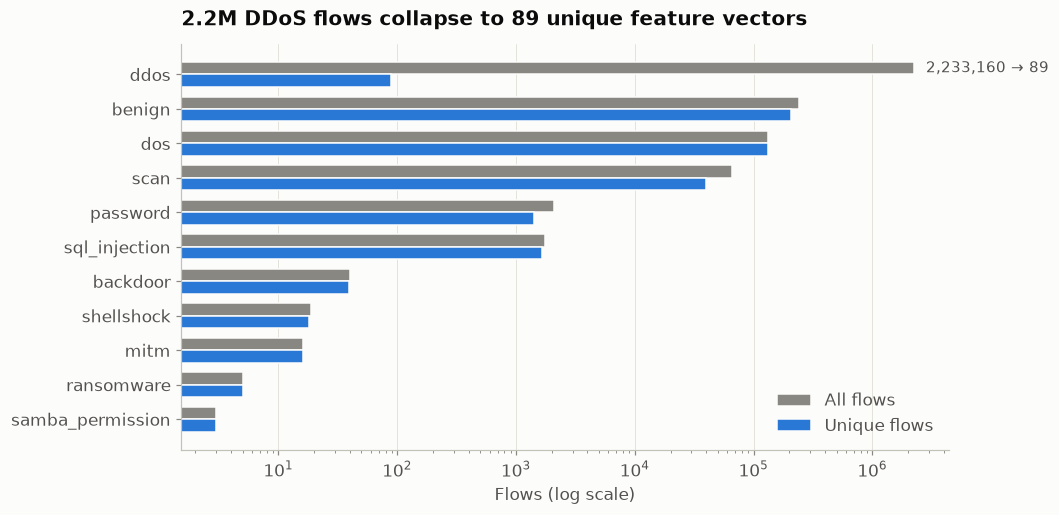

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
order = dedup.index[::-1]
y = np.arange(len(order))
h = 0.36
ax.barh(y + h / 2, dedup.loc[order, "raw flows"], height=h, color=MUTED, edgecolor=SURFACE, linewidth=1, label="All flows")
ax.barh(y - h / 2, dedup.loc[order, "unique flows"], height=h, color=BLUE, edgecolor=SURFACE, linewidth=1, label="Unique flows")
ax.set_xscale("log")
ax.set_yticks(y, order)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Flows (log scale)")
ax.set_title("2.2M DDoS flows collapse to 89 unique feature vectors")
ddos_y = list(order).index("ddos")
ax.annotate("2,233,160 → 89", xy=(dedup.loc["ddos", "raw flows"], ddos_y + h / 2), xytext=(8, 0),
            textcoords="offset points", va="center", color=INK_2, fontsize=10)
ax.legend(loc="lower right")
common.save(fig, "net_01_duplicates")
plt.show()

### Group rare classes and split

Backdoor, MITM, ransomware, samba_permission and shellshock have 40 flows or fewer each, so they are grouped into `other`.
The split is a 70/30 **stratified** split, which keeps the class proportions equal in train and test.

In [5]:
SMALL = ["backdoor", "mitm", "ransomware", "samba_permission", "shellshock"]
data["cls"] = data["label"].where(~data["label"].isin(SMALL), "other")
CLASSES = ["benign", "ddos", "dos", "scan", "password", "sql_injection", "other"]

train, test = train_test_split(data, test_size=0.3, stratify=data["cls"], random_state=SEED)
pd.DataFrame({"train": train["cls"].value_counts(), "test": test["cls"].value_counts()}).loc[CLASSES]

,train,test
cls,,
benign,144368,61872
ddos,62,27
dos,91761,39326
scan,27619,11836
password,996,427
sql_injection,1165,500
other,57,24


## 2. Models

| Model | Preprocessing | Why |
|---|---|---|
| **LR** | missing values → median, standardize | baseline linear model |
| **LR + log** | same + signed log1p transform | flow features span 0 to millions (heavy-tailed), which hurts a linear model; how much does a log transform help? |
| **DT** | missing values → median | scale-free and learns threshold rules; depth limited to 10 to stay readable and avoid overfitting |

Logistic regression may hit its iteration limit (`max_iter=2000`) before fully converging on these heavy-tailed features; the notebook silences that warning.
Its scores can therefore shift by about a percentage point between scikit-learn versions. The conclusions do not change.

In [6]:
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


def make_models():
    return {
        "LR": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                            LogisticRegression(max_iter=2000)),
        "LR + log": make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(signed_log1p),
                                  StandardScaler(), LogisticRegression(max_iter=2000)),
        "DT": make_pipeline(SimpleImputer(strategy="median"),
                            DecisionTreeClassifier(max_depth=10, random_state=SEED)),
    }


MODEL_COLORS = {"LR": BLUE, "LR + log": AQUA, "DT": ORANGE}

## 3. Binary: benign vs attack

In [7]:
binary_models, binary_pred = make_models(), {}
for name, model in binary_models.items():
    model.fit(train[features], train["is_attack"])
    binary_pred[name] = model.predict(test[features])

binary_scores = pd.DataFrame({
    name: {"accuracy": accuracy_score(test["is_attack"], p), "F1": f1_score(test["is_attack"], p)}
    for name, p in binary_pred.items()
}).T.round(4)
binary_scores

,accuracy,F1
LR,0.9993,0.9992
LR + log,0.9998,0.9998
DT,0.9999,0.9999


All three models score above 99.9%, so the binary task shows no difference between them.

### But what about *real* benign traffic?

98.5% of the benign flows are **synthetic** traffic generated with Scapy; only 3,616 benign flows were captured in the real microgrid lab.
Split the benign test flows by source and compare the false positive rate (benign traffic flagged as an attack).

In [8]:
benign_test = test["is_attack"] == 0
fpr = pd.DataFrame({
    name: {
        src: p[benign_test & (test["source"] == src)].mean() * 100
        for src in ["synthetic_benign", "original_benign"]
    }
    for name, p in binary_pred.items()
}).round(2)
fpr.index = ["Synthetic benign", "Original benign (microgrid lab)"]
print("False positive rate (%)")
print("test flows:", test.loc[benign_test, "source"].value_counts().to_dict())
fpr

False positive rate (%)
test flows: {'synthetic_benign': 60813, 'original_benign': 1059, 'attack_capture': 0}


,LR,LR + log,DT
Synthetic benign,0.01,0.00,0.01
Original benign (microgrid lab),4.44,1.51,0.38


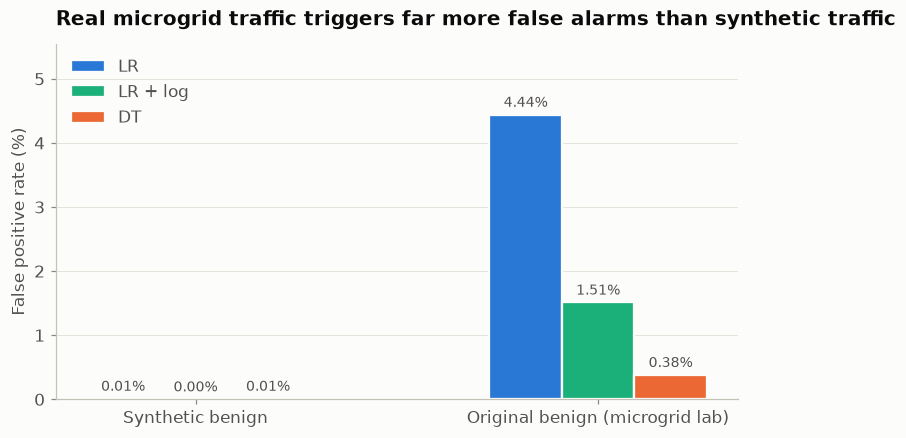

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(fpr.index))
w = 0.18
for i, name in enumerate(fpr.columns):
    bars = ax.bar(x + (i - 1) * w, fpr[name], width=w, color=MODEL_COLORS[name],
                  edgecolor=SURFACE, linewidth=1.5, label=name)
    ax.bar_label(bars, labels=[f"{v:.2f}%" for v in fpr[name]], padding=3, color=INK_2, fontsize=9)
ax.set_xticks(x, fpr.index)
ax.grid(axis="x", visible=False)
ax.set_ylabel("False positive rate (%)")
ax.set_ylim(0, fpr.values.max() * 1.25)
ax.set_title("Real microgrid traffic triggers far more false alarms than synthetic traffic")
ax.legend(loc="upper left")
common.save(fig, "net_02_false_positive_rate")
plt.show()

The models separate *synthetic* benign traffic from attacks very well, but raise many more false alarms on **real** benign traffic (LR above all).
When you use this dataset, keep in mind that most benign data is synthetic.

## 4. Multi-class: which attack is it?

In [10]:
multi_models, multi_pred = make_models(), {}
for name, model in multi_models.items():
    model.fit(train[features], train["cls"])
    multi_pred[name] = model.predict(test[features])

multi_scores = pd.DataFrame({
    name: {"accuracy": accuracy_score(test["cls"], p), "macro F1": f1_score(test["cls"], p, average="macro")}
    for name, p in multi_pred.items()
}).T.round(4)
multi_scores

,accuracy,macro F1
LR,0.9969,0.6838
LR + log,0.9985,0.8824
DT,0.9993,0.9138


In [11]:
for name in ["LR", "DT"]:
    print(f"===== {name}")
    print(classification_report(test["cls"], multi_pred[name], labels=CLASSES, digits=3, zero_division=0))

===== LR


               precision    recall  f1-score   support

       benign      1.000     0.999     0.999     61872
         ddos      0.000     0.000     0.000        27
          dos      1.000     1.000     1.000     39326
         scan      0.995     0.996     0.995     11836
     password      0.686     0.946     0.795       427
sql_injection      0.851     0.652     0.738       500
        other      0.571     0.167     0.258        24

     accuracy                          0.997    114012
    macro avg      0.729     0.680     0.684    114012
 weighted avg      0.997     0.997     0.997    114012

===== DT


               precision    recall  f1-score   support

       benign      1.000     1.000     1.000     61872
         ddos      0.900     1.000     0.947        27
          dos      1.000     1.000     1.000     39326
         scan      0.999     0.998     0.998     11836
     password      0.949     0.995     0.971       427
sql_injection      0.972     0.960     0.966       500
        other      0.818     0.375     0.514        24

     accuracy                          0.999    114012
    macro avg      0.948     0.904     0.914    114012
 weighted avg      0.999     0.999     0.999    114012



**Accuracy is above 99.7% for all three, but macro-F1 differs a lot.** More than 98% of the test set is benign, DoS or scan, so accuracy hides failures on the small classes.
Macro-F1 averages the per-class F1 scores, giving every class the same weight, which exposes the difference.

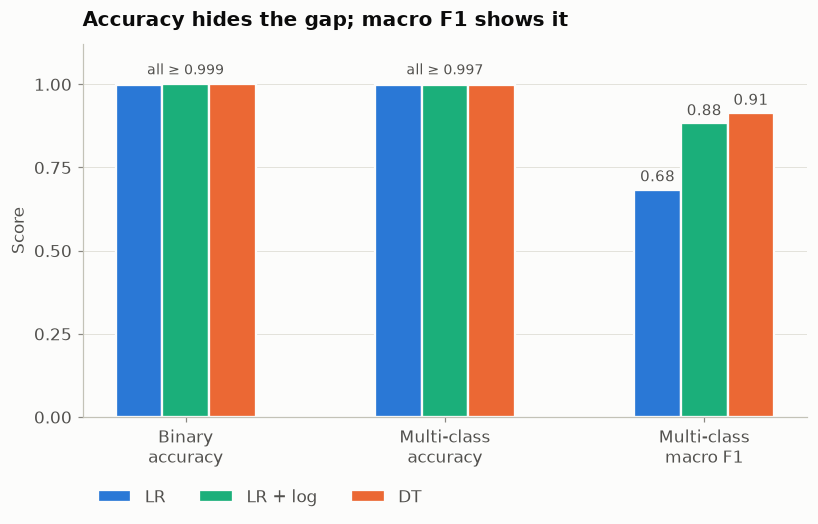

In [12]:
summary = pd.DataFrame({
    "Binary\naccuracy": binary_scores["accuracy"],
    "Multi-class\naccuracy": multi_scores["accuracy"],
    "Multi-class\nmacro F1": multi_scores["macro F1"],
}).T

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(summary.index))
w = 0.18
for i, name in enumerate(summary.columns):
    bars = ax.bar(x + (i - 1) * w, summary[name], width=w, color=MODEL_COLORS[name],
                  edgecolor=SURFACE, linewidth=1.5, label=name)
    ax.bar_label(bars, labels=["", "", f"{summary[name].iloc[-1]:.2f}"], padding=3, color=INK_2, fontsize=10)
ax.text(0, 1.03, "all ≥ 0.999", ha="center", color=INK_2, fontsize=9)
ax.text(1, 1.03, "all ≥ 0.997", ha="center", color=INK_2, fontsize=9)
ax.set_xticks(x, summary.index)
ax.grid(axis="x", visible=False)
ax.set_ylim(0, 1.12)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_ylabel("Score")
ax.set_title("Accuracy hides the gap; macro F1 shows it")
ax.legend(loc="lower left", ncols=3, bbox_to_anchor=(0, -0.28))
common.save(fig, "net_03_scores")
plt.show()

### Recall per class: where does LR fail?

In [13]:
support = test["cls"].value_counts()
recall = pd.DataFrame({
    name: recall_score(test["cls"], p, labels=CLASSES, average=None, zero_division=0)
    for name, p in multi_pred.items()
}, index=CLASSES).round(3)
recall.insert(0, "test n", support.loc[CLASSES])
recall

,test n,LR,LR + log,DT
benign,61872,0.999,1.000,1.000
ddos,27,0.000,0.963,1.000
dos,39326,1.000,1.000,1.000
scan,11836,0.996,0.996,0.998
password,427,0.946,0.892,0.995
sql_injection,500,0.652,0.902,0.960
other,24,0.167,0.417,0.375


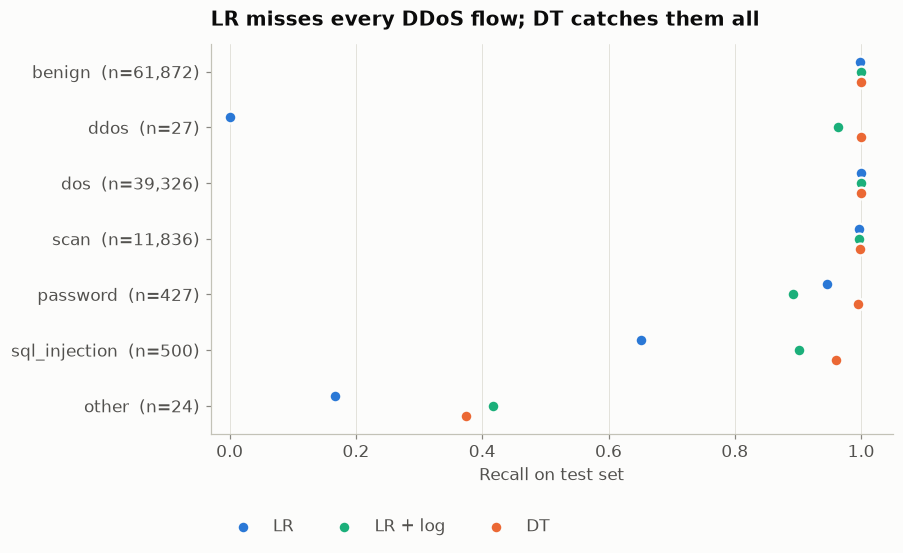

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.6))
order = CLASSES[::-1]
y = np.arange(len(order))
for name, dy in [("LR", 0.18), ("LR + log", 0), ("DT", -0.18)]:
    ax.scatter(recall.loc[order, name], y + dy, s=60, color=MODEL_COLORS[name],
               edgecolor=SURFACE, linewidth=1.5, label=name, zorder=3)
ax.set_yticks(y, [f"{c}  (n={support[c]:,})" for c in order])
ax.set_xlim(-0.03, 1.05)
ax.set_xlabel("Recall on test set")
ax.grid(axis="y", visible=False)
ax.set_title("LR misses every DDoS flow; DT catches them all")
ax.legend(loc="lower left", ncols=3, bbox_to_anchor=(0, -0.3))
common.save(fig, "net_04_recall_by_class")
plt.show()

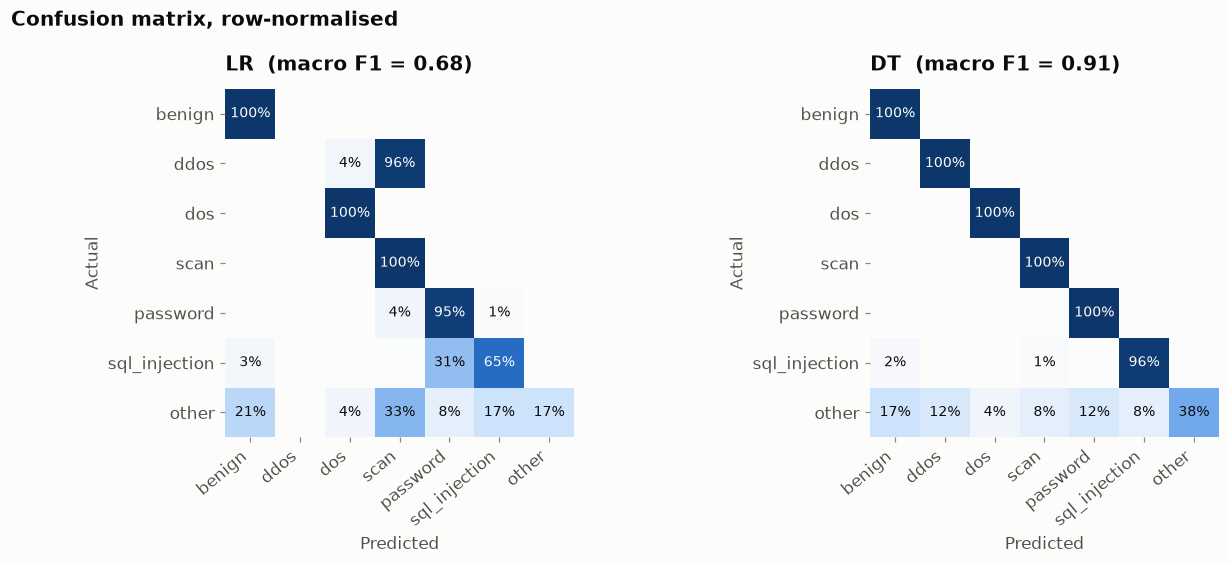

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, name in zip(axes, ["LR", "DT"]):
    cm = confusion_matrix(test["cls"], multi_pred[name], labels=CLASSES, normalize="true")
    ax.imshow(cm, cmap=BLUES, vmin=0, vmax=1)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            if cm[i, j] >= 0.005:
                ax.text(j, i, f"{cm[i, j]:.0%}", ha="center", va="center", fontsize=9,
                        color=SURFACE if cm[i, j] > 0.55 else INK)
    ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=40, ha="right")
    ax.set_yticks(range(len(CLASSES)), CLASSES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(f"{name}  (macro F1 = {multi_scores.loc[name, 'macro F1']:.2f})")
fig.suptitle("Confusion matrix, row-normalised", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
common.save(fig, "net_05_confusion")
plt.show()

- **LR labels 96% of DDoS flows as scan.** A DDoS flow is a single SYN packet from a spoofed source, which looks like a port scan at the flow level; one linear boundary cannot separate them.
- DT gets every DDoS flow right, but both models struggle with `other` (81 unique flows of backdoor, MITM, …): it has only 57 training samples.

## 5. What the models looked at

- DT: feature importance (total impurity reduction)
- LR: absolute coefficient of the standardized feature, averaged over classes

Flow features are strongly correlated (e.g. `Tot Fwd Pkts` and `Subflow Fwd Pkts`), so treat the LR coefficients as a rough guide only.

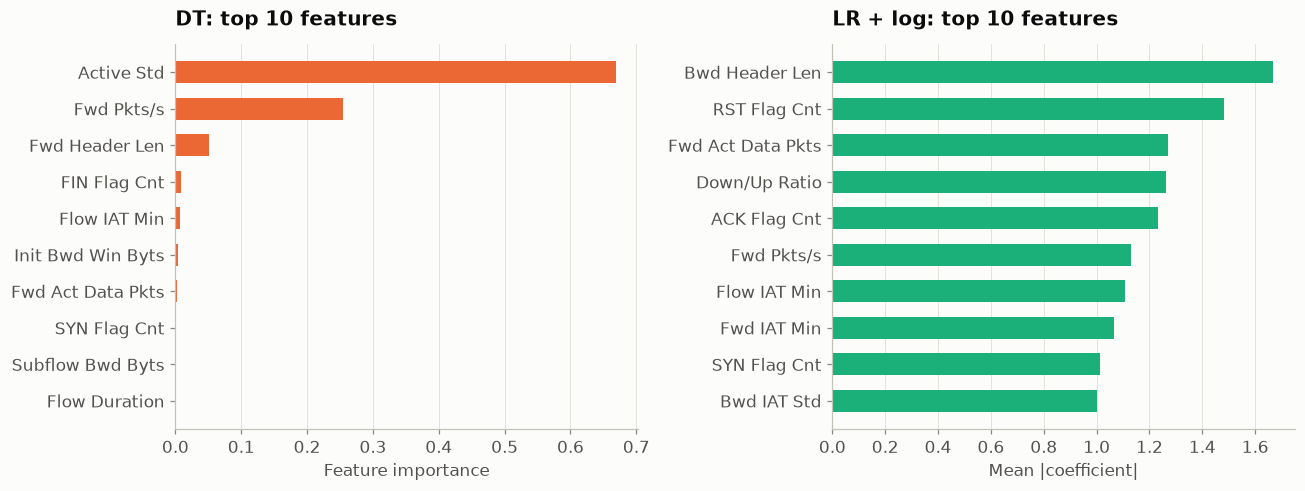

In [16]:
dt = multi_models["DT"][-1]
lr = multi_models["LR + log"][-1]
dt_imp = pd.Series(dt.feature_importances_, index=features).nlargest(10)
lr_imp = pd.Series(np.abs(lr.coef_).mean(axis=0), index=features).nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, imp, name, xlabel in [(axes[0], dt_imp, "DT", "Feature importance"),
                              (axes[1], lr_imp, "LR + log", "Mean |coefficient|")]:
    imp = imp[::-1]
    ax.barh(imp.index, imp.values, height=0.6, color=MODEL_COLORS[name])
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(xlabel)
    ax.set_title(f"{name}: top 10 features")
fig.tight_layout()
common.save(fig, "net_06_top_features")
plt.show()

The top of the rules the tree learned. Human-readable if-then rules are the main strength of a decision tree.

In [17]:
print(export_text(dt, feature_names=features, max_depth=3, decimals=1))

|--- Active Std <= 3084563.4
|   |--- Fwd Pkts/s <= 26.1
|   |   |--- FIN Flag Cnt <= 0.5
|   |   |   |--- Fwd Pkts/s <= 22.9
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- Fwd Pkts/s >  22.9
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- FIN Flag Cnt >  0.5
|   |   |   |--- Init Bwd Win Byts <= 238.5
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- Init Bwd Win Byts >  238.5
|   |   |   |   |--- truncated branch of depth 7
|   |--- Fwd Pkts/s >  26.1
|   |   |--- Fwd Header Len <= 22.0
|   |   |   |--- SYN Flag Cnt <= 0.5
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- SYN Flag Cnt >  0.5
|   |   |   |   |--- class: ddos
|   |   |--- Fwd Header Len >  22.0
|   |   |   |--- Fwd Header Len <= 28.0
|   |   |   |   |--- class: scan
|   |   |   |--- Fwd Header Len >  28.0
|   |   |   |   |--- truncated branch of depth 7
|--- Active Std >  3084563.4
|   |--- Flow IAT Min <= 5.5
|   |   |--- Bwd Pkt Len Mean <= 482.3
|   | 

What does the tree's first (root) split separate?

In [18]:
root_feature, root_threshold = features[dt.tree_.feature[0]], dt.tree_.threshold[0]
above = (data[root_feature] > root_threshold).groupby(data["cls"]).mean().loc[CLASSES]
print(f"Root split: {root_feature} > {root_threshold:,.0f}")
(above * 100).round(1).rename("% of flows above threshold").to_frame()

Root split: Active Std > 3,084,563


,% of flows above threshold
cls,
benign,0.2
ddos,3.4
dos,100.0
scan,0.0
password,0.0
sql_injection,0.1
other,0.0


That single split **separates all DoS flows (100%) from the other classes.** `Active Std` measures how much the active periods inside a flow vary in length, and it is large for long-lived flood connections.
DoS is a third of the data, which is why this one split earns an importance of 0.67.

## 6. Summary

| Observation | What it means |
|---|---|
| 2.23 M DDoS flows → 89 unique patterns | Many flows ≠ diverse data. Test scores without deduplication are inflated. |
| Binary: LR and DT both ≥ 0.999 | On this data, "attack or not" is an easy question. |
| Multi-class macro-F1: LR 0.68 → LR + log 0.88 → DT 0.91 | Linear models depend on preprocessing; trees catch small classes with threshold rules. |
| LR mistakes DDoS for scan | A single-SYN flood looks like a port scan at the flow level. |
| Many more false alarms on real microgrid benign traffic | Most benign data is synthetic, so performance on real traffic needs a separate check. |

## Things to try

1. Train on synthetic benign traffic only and evaluate on the 3,616 real benign flows. How do the false positive rates change?
2. Split train/test by capture file (the `capture` column) instead of at random, so no capture appears on both sides.
3. Add a random forest or gradient boosting model. Does it close the gap on the `other` class?
4. Put `Dst Port` back in as a feature. What happens to the scores, and why is that misleading?
5. Change `max_depth` from 2 to 30 and plot macro-F1 for train and test to see overfitting.